# แบบฝึกหัด 2: Training Data
**กลุ่ม/ผู้จัดทำ:**
**6810405691 ปิยังกูร ปัสสาวะกัง บรรยาย หมู่ 1 ปฏิบัติ หมู่ 11**
**6810405887 ศิวภูมิ พรหมจรรย์ บรรยาย หมู่ 1 ปฏิบัติ หมู่ 11**



---

### การเปิดเผยการใช้งาน AI (AI Disclosure)
 Notebookเล่มนี้มีการใช้aiเพื่อช่วยในการร่างโครงสร้างภาษาไทยของคำอธิบายทางวิชาการและแนวคิดเชิงวิศวกรรมข้อมูล รวมถึงการตรวจสอบโครงร่างของสคริปต์สำหรับการวิเคราะห์สถิติและการวาดกราฟ ผู้จัดทำได้ทำการปรับปรุงและแก้ไขเนื้อหา ตรวจสอบรหัสโปรแกรม รันการคำนวณกับไฟล์ชุดข้อมูลจริง `PlantCLEF2024_single_plant_training_metadata.csv` และประเมินผลลัพธ์สุดท้ายด้วยตนเองเพื่อให้เนื้อหาและการวิเคราะห์มีความถูกต้องและตรงตามข้อเท็จจริงของชุดข้อมูล

---

## 1. การสุ่มตัวอย่างข้อมูล (Sampling Analysis)

### 1.1 วิธีการสุ่มตัวอย่าง (Sampling Method) ที่ข้อมูลใช้อยู่
ชุดข้อมูลฝึกฝนของ **PlantCLEF 2026** (ซึ่งพัฒนาและอ้างอิงฐานข้อมูลจากเครือข่าย Pl@ntNet, iNaturalist และ GBIF) ใช้การสุ่มตัวอย่างแบบ **Opportunistic Sampling (การสุ่มตัวอย่างแบบบังเอิญ/ตามโอกาส)** หรือเรียกว่า **Voluntary Response / Citizen Science Sampling**
* **เหตุผล:** ข้อมูลในชุดนี้ไม่ได้มาจากการสุ่มสำรวจแปลงป่าอย่างมีระเบียบแผนล่วงหน้า (เช่น การใช้ Quadrats หรือ Systematic Sampling ในแต่ละเขตพื้นที่พฤกษศาสตร์) แต่มาจากการที่นักปีนเขา นักธรรมชาติวิทยา หรือประชาชนทั่วไปเดินไปพบพืชตามป่า สวนสาธารณะ หรือริมทาง แล้วใช้สมาร์ตโฟนถ่ายภาพอัปโหลดเข้าสู่ระบบ ดังนั้นปริมาณและตำแหน่งการกระจายตัวของภาพพืชแต่ละชนิดจึงขึ้นอยู่กับประชากรมนุษย์ ความนิยมของพื้นที่ท่องธรรมชาติ และความสะดุดตาของสายพันธุ์พืชนั้น ๆ (เช่น พืชที่มีดอกไม้สวยงามมักมีผู้ถ่ายภาพมากกว่าหญ้าหรือพืชล้มลุกทั่วไป)

### 1.2 วิธีการสุ่มตัวอย่างที่ควรใช้สำหรับการสร้าง Validation / Test Split
สำหรับการแบ่งชุดข้อมูลเพื่อสอนและประเมินผลตัวแบบ (Model Evaluation) ในระบบทดสอบ วิธีการที่เหมาะสมที่สุดคือ **Stratified Sampling (การสุ่มตัวอย่างแบบแบ่งชั้นภูมิ)** โดยใช้ `species_id` เป็นตัวแบ่งชั้น (Stratum)
* **เหตุผล:** ชุดข้อมูลนี้มีจำนวนประเภทคลาสสูงมาก (7,806 ชนิด) และแต่ละชนิดมีจำนวนรูปภาพที่ไม่เท่ากันอย่างรุนแรง (ตั้งแต่ 1 รูปไปจนถึง 823 รูป) หากเราใช้วิธี **Simple Random Sampling (การสุ่มตัวอย่างแบบง่าย)** จะมีความเสี่ยงสูงมากที่คลาสพืชที่มีรูปภาพน้อย (เช่น มีเพียง 1-3 รูป) จะหลุดไปอยู่ในชุดใดชุดหนึ่งทั้งหมด ทำให้โมเดลไม่มีโอกาสได้เรียนรู้ในชุด Train หรือไม่มีข้อมูลสำหรับทดสอบความถูกต้องในชุด Validation ส่งผลให้ตัวชี้วัดประสิทธิภาพเชิงภาพรวม (เช่น Macro F1-score) ผิดเพี้ยนไป

### 1.3 ปัญหาที่อาจเกิดขึ้นจากวิธีการสุ่มตัวอย่างและแนวทางแก้ไข

| ปัญหาที่อาจเกิดขึ้น | รายละเอียดของปัญหา | แนวทางการแก้ไขเชิงวิศวกรรมข้อมูล |
| :--- | :--- | :--- |
| **1. Domain Shift / Selection Bias** | ข้อมูลรูปภาพถ่ายในสภาวะแวดล้อมที่จำกัด (เช่น ถ่ายเฉพาะพืชในแถบยุโรปที่มีคนใช้งานแอปเยอะ หรือภาพมีคุณภาพสูงเนื่องจากโทรศัพท์รุ่นใหม่) เมื่อนำไปใช้ทดสอบกับภาพพืชป่าจากพื้นที่อื่นหรือกล้องชนิดอื่น โมเดลจะทำงานได้ไม่ดี | ใช้เทคนิค **Domain Augmentation** หรือรวบรวมข้อมูลภายนอกมาเสริม และกำหนดกระบวนการทำความสะอาดภาพให้มีความหลากหลายด้านแสง/มุมกล้อง |
| **2. Zero-shot / Few-shot Classes** | คลาสพืชหายากบางประเภทมีรูปภาพเพียงรูปเดียวในระบบ ทำให้ไม่สามารถแบ่งชุดข้อมูลด้วย Stratified Sampling ตามปกติได้ (เนื่องจากมีจำนวนข้อมูลไม่พอที่จะแบ่งเป็น Train และ Val) | แยกกลุ่มสายพันธุ์ที่หายากสุดขีด (เช่น มีภาพ < 3 ภาพ) ออกมาจัดการเฉพาะตัว โดยอาจใช้การทำ **Data Augmentation** เพื่อโคลนภาพ หรือใช้กระบวนการเรียนรู้แบบ **Few-shot Learning / Siamese Networks** หรือจัดให้อยู่ในกลุ่ม Train ทั้งหมดและประเมินผลผ่าน Out-of-Distribution (OOD) |
| **3. Spatial Auto-correlation** | ภาพหลายภาพของพืชชนิดเดียวกันอาจมาจากสถานที่เดียวกันและพืชต้นเดียวกันในเวลาไล่เลี่ยกัน (เช่น ถ่ายรูปมุมต่าง ๆ ของต้นไม้ต้นเดิม 10 รูป) ทำให้ข้อมูลมีความสัมพันธ์กันเองสูง หากหลุดไปอยู่ทั้งใน Train และ Val จะทำให้เกิดการประเมินประสิทธิภาพที่สูงเกินจริง (Overoptimistic) | ใช้ **Group-based Stratified Sampling** โดยยึดตามคอลัมน์รหัสการสังเกตการณ์ (`obs_id`) เพื่อให้แน่ใจว่ารูปภาพที่มาจากพืชต้นเดียวกันหรือทริปเดียวกันจะไม่ถูกแยกออกไปอยู่คนละชุดข้อมูลกัน |

## 2. การกำหนดเฉลยข้อมูล (Labeling Analysis)

### 2.1 วิธีการกำหนดเฉลย (Labeling Method) ที่ข้อมูลใช้อยู่
ชุดข้อมูลของ PlantCLEF ใช้ระบบ **Hybrid Labeling (ระบบผสมผสาน)** ซึ่งเริ่มต้นด้วย **Crowdsourcing (การระบุชื่อพืชโดยผู้ใช้ทั่วไป)** และตามด้วยกระบวนการ **Consensus Voting (ฉันทามติของกลุ่ม)** ร่วมกับการสกรีนขั้นตอนสุดท้ายโดย **Expert Validation (ผู้เชี่ยวชาญ/นักพฤกษศาสตร์)** จากแพลตฟอร์มพฤกษศาสตร์พลเมืองอย่าง Pl@ntNet และ iNaturalist
* **เหตุผล:** เนื่องจากรูปภาพมีจำนวนมหาศาลกว่า 1.4 ล้านภาพ และมีสายพันธุ์สูงถึงเกือบ 8,000 ชนิด การพึ่งพาเฉพาะผู้เชี่ยวชาญเพียงอย่างเดียวตั้งแต่แรกเป็นไปไม่ได้เนื่องจากข้อจำกัดด้านเวลา ค่าจ้างแรงงาน และจำนวนบุคลากร การเปิดให้คนทั่วไปอัปโหลดและเสนอรหัสสายพันธุ์ (Crowdsourcing) แล้วสร้างคะแนนความน่าเชื่อถือจากความเห็นพ้องต้องกันของระบบ (Consensus) จึงเป็นวิธีเดียวที่สามารถผลิตข้อมูลขนาดใหญ่ระดับล้านภาพนี้ได้

### 2.2 ปัญหาที่อาจเกิดขึ้นจากวิธีการกำหนดเฉลยและแนวทางแก้ไข

| ปัญหาที่อาจเกิดขึ้น | รายละเอียดของปัญหา | แนวทางการแก้ไขเชิงวิศวกรรมข้อมูล |
| :--- | :--- | :--- |
| **1. Label Noise (ข้อมูลเฉลยผิดพลาด)** | สมาชิกผู้เสนออาจขาดทักษะพฤกษศาสตร์ ทำให้จำแนกสายพันธุ์พืชที่คล้ายคลึงกัน (Look-alike species) ผิดพลาด หรือป้อนป้ายกำกับเฉลยที่ไม่ถูกต้องเข้าสู่ระบบ ซึ่งจะส่งผลให้ประสิทธิภาพการฝึกอบรมโมเดลลดลง | 1. ใช้สถิติ **Consensus Score** หรือเกณฑ์คะแนนความน่าเชื่อถือของผู้ตรวจเพื่อกรองภาพเฉลยที่ไม่แน่นอนออกก่อนฝึกสอน<br>2. ประยุกต์ใช้ซอฟต์แวร์ตรวจหาความผิดปกติของข้อมูลเฉลย เช่น **Cleanlab** หรือรันอัลกอริทึม **Self-supervised Label Cleaning** เพื่อหาจุดข้อมูลที่น่าจะระบุชนิดพืชผิดแล้วแก้ไขคลาสพืชให้ถูกต้อง |
| **2. Coarse-grained Labeling** | การระบุป้ายเฉลยทำได้ไม่ละเอียดพอ เช่น กำหนดได้เพียงระดับสกุล (Genus) หรือวงศ์ (Family) แต่ไม่ระบุลึกถึงระดับชนิด (Species) ส่งผลต่อคุณภาพของคลาสเป้าหมายในการแข่งขัน | ใช้ข้อมูลความสัมพันธ์ของต้นไม้สายพันธุ์จำแนกแบบลำดับชั้น (**Hierarchical Classification**) เพื่อช่วยคำนวณหาคลาสที่มีความสัมพันธ์ใกล้ชิดทางพันธุกรรมแทนการระบุแบบแยกขาดอย่างเดียว |
| **3. Expert Bottleneck** | การระบุพืชชนิดหายากหรือมีลักษณะใกล้เคียงกันอย่างยิ่งต้องอาศัยผู้เชี่ยวชาญที่มีเวลาและกำลังความสามารถอย่างจำกัด ทำให้ข้อมูลในส่วนนี้ได้รับการยืนยันเฉลยช้าและมีคลาสที่ค้างสถานะรอการตัดสินใจจำนวนมาก | นำเทคนิค **Active Learning** มาใช้เลือกรูปภาพเฉพาะที่โมเดลมีความไม่มั่นใจในการทำนายสูงสุด ส่งต่อให้ผู้เชี่ยวชาญตรวจสอบเฉลยด้วยมือ วิธีนี้ช่วยลดภาระงานตรวจทานของผู้เชี่ยวชาญลงไปได้มากกว่า 80-90% |

## 3. การวิเคราะห์ระดับความไม่สมดุลของข้อมูล (Class Imbalance Analysis)

ในการวิเคราะห์ส่วนนี้ เราจะทำการเขียนโค้ด Python เพื่อโหลดชุดข้อมูลสรุปรายการอ้างอิง `PlantCLEF2024_single_plant_training_metadata.csv` ค้นหาค่าสถิติระบุสัดส่วนการแจกแจงของภาพพืช และพล็อตกราฟแจกแจงประชากรภาพในคลาสต่าง ๆ

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ค้นหาตำแหน่งไฟล์อัตโนมัติป้องกัน FileNotFoundError
filename = 'PlantCLEF2024_single_plant_training_metadata.csv'
search_paths = [
    filename,                       # โฟลเดอร์เดียวกับ Notebook
    f'./{filename}',                 # โฟลเดอร์ปัจจุบัน
    f'../{filename}',                # ย้อนกลับ 1 ชั้น
    f'./data/{filename}',            # โฟลเดอร์ data
    f'../data/{filename}',           # โฟลเดอร์ data (ย้อนกลับ 1 ชั้น)
    f'/content/{filename}',          # Google Colab Root
    f'/kaggle/input/{filename}'     # Kaggle Input
]

metadata_path = None
for path in search_paths:
    if os.path.exists(path):
        metadata_path = path
        break

# หากค้นหาไม่พบ จะแจ้งเตือนตำแหน่ง Directory ปัจจุบันเพื่อช่วยตรวจสอบ
if metadata_path is None:
    print("❌ ไม่พบไฟล์ใน Path ที่ระบุ!")
    print("📍 ตำแหน่ง Directory ปัจจุบันของคุณคือ:", os.getcwd())
    print("📂 รายชื่อไฟล์ทั้งหมดในโฟลเดอร์นี้:", os.listdir('.'))
    raise FileNotFoundError(f"กรุณาย้ายไฟล์ '{filename}' มาวางในตำแหน่งเดียวกับ Notebook")

# 2. ตั้งค่าธีมการแสดงผล
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 11

# 3. โหลดข้อมูล
print(f"กำลังโหลดและประมวลผลข้อมูลจาก: {metadata_path}")
df = pd.read_csv(metadata_path, sep=';', low_memory=False)
print("โหลดข้อมูลเสร็จสิ้น!")

กำลังโหลดและประมวลผลข้อมูลจาก: PlantCLEF2024_single_plant_training_metadata.csv
โหลดข้อมูลเสร็จสิ้น!


In [8]:
# 1. คำนวณค่าสถิติเชิงปริมาณหลัก
total_images = len(df)
num_classes = df['species_id'].nunique()
class_counts = df['species_id'].value_counts()

min_count = class_counts.min()
max_count = class_counts.max()
mean_count = class_counts.mean()
median_count = class_counts.median()
imbalance_ratio = max_count / min_count

print("=== สรุปผลการวัดระดับความไม่สมดุลของข้อมูล (Class Imbalance Metrics) ===")
print(f"- จำนวนข้อมูลรูปภาพทั้งหมด: {total_images:,} ภาพ")
print(f"- จำนวนสายพันธุ์พืชพรรณที่แตกต่างกัน (Classes): {num_classes:,} สายพันธุ์")
print(f"- จำนวนรูปภาพต่ำสุดของสายพันธุ์ที่พบน้อยที่สุด: {min_count} ภาพ")
print(f"- จำนวนรูปภาพสูงสุดของสายพันธุ์ที่พบมากที่สุด: {max_count} ภาพ")
print(f"- ค่าเฉลี่ยจำนวนรูปภาพต่อสายพันธุ์ (Mean): {mean_count:.2f} ภาพ")
print(f"- ค่ามัธยฐานจำนวนรูปภาพต่อสายพันธุ์ (Median): {median_count:.2f} ภาพ")
print(f"- อัตราส่วนความไม่สมดุล (Imbalance Ratio = Max/Min): {imbalance_ratio:.2f}")

=== สรุปผลการวัดระดับความไม่สมดุลของข้อมูล (Class Imbalance Metrics) ===
- จำนวนข้อมูลรูปภาพทั้งหมด: 1,408,033 ภาพ
- จำนวนสายพันธุ์พืชพรรณที่แตกต่างกัน (Classes): 7,806 สายพันธุ์
- จำนวนรูปภาพต่ำสุดของสายพันธุ์ที่พบน้อยที่สุด: 1 ภาพ
- จำนวนรูปภาพสูงสุดของสายพันธุ์ที่พบมากที่สุด: 823 ภาพ
- ค่าเฉลี่ยจำนวนรูปภาพต่อสายพันธุ์ (Mean): 180.38 ภาพ
- ค่ามัธยฐานจำนวนรูปภาพต่อสายพันธุ์ (Median): 176.00 ภาพ
- อัตราส่วนความไม่สมดุล (Imbalance Ratio = Max/Min): 823.00


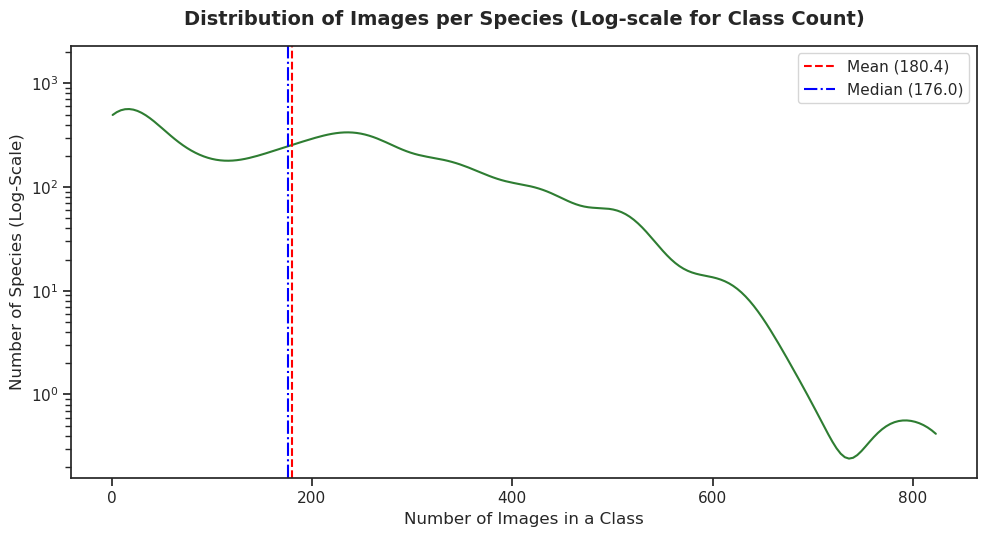

In [9]:
# 2. พล็อตกราฟการแจกแจงของจำนวนรูปภาพต่อสายพันธุ์พืช (Class Size Distribution)
plt.figure(figsize=(10, 5.5))
sns.histplot(class_counts.values, bins=50, color='#2e7d32', kde=True, log_scale=(False, True))
plt.title('Distribution of Images per Species (Log-scale for Class Count)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Images in a Class', fontsize=12)
plt.ylabel('Number of Species (Log-Scale)', fontsize=12)
plt.axvline(mean_count, color='red', linestyle='--', linewidth=1.5, label=f'Mean ({mean_count:.1f})')
plt.axvline(median_count, color='blue', linestyle='-.', linewidth=1.5, label=f'Median ({median_count:.1f})')
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig('species_distribution_plot.png', dpi=300)
plt.show()

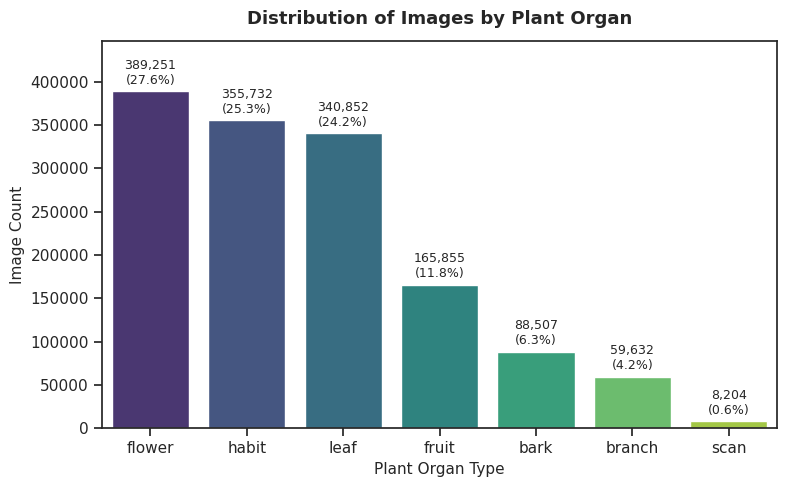

In [10]:
# 3. ตรวจสอบการแจกแจงของข้อมูลแยกตามอวัยวะพืช (Organ Distribution)
organ_counts = df['organ'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=organ_counts.index, y=organ_counts.values, hue=organ_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Images by Plant Organ', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Plant Organ Type', fontsize=11)
plt.ylabel('Image Count', fontsize=11)
for i, val in enumerate(organ_counts.values):
    plt.text(i, val + 5000, f'{val:,}\n({val/total_images*100:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.ylim(0, max(organ_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('organ_distribution_plot.png', dpi=300)
plt.show()

### 3.1 ผลกระทบจากระดับความไม่สมดุลของข้อมูลต่อโมเดล
จากการคำนวณสถิติเบื้องต้น พบว่า:
1. **Imbalance Ratio สูงถึง 823.00 เท่า:** โดยมีพืชบางชนิดที่มีรูปภาพประกอบมากถึง 823 รูป ในขณะที่มีสายพันธุ์บางชนิดที่มีรูปภาพสนับสนุนเพียง 1 รูปเท่านั้น ซึ่งเป็นสภาพความไม่สมดุลในระดับสูงมาก (**Severe Class Imbalance**)
2. **สถิติเฉลี่ยและมัธยฐานค่อนข้างใกล้กัน:** (Mean = 180.38, Median = 176.00) แสดงให้เห็นว่าการกระจายตัวค่อนข้างหนาแน่นอยู่ในช่วงปานกลาง แต่ความไม่สมดุลสุดขั้วนั้นเกิดขึ้นจากค่ากลุ่มปลายสุด (Tail distribution) ที่มีปริมาณภาพต่ำมากและคลาสยอดนิยมที่มีภาพสูงมาก

**ผลกระทบต่อแบบจำลองทางปัญญาประดิษฐ์:**
* **โมเดลมีความเอนเอียง (Majority Class Bias):** ตัวแบบโครงข่ายประสาทเทียมลึก (Deep Neural Networks) จะเรียนรู้การทำนายเน้นหนักไปทางสายพันธุ์ยอดนิยมที่มีภาพจำนวนมาก เช่น คลาสที่มีรูปภาพหลักร้อยภาพ เพื่อลดค่าความสูญเสียโดยรวม (Overall Loss)
* **ผลการวัดแบบหลอกลวง (Accuracy Paradox):** แม้โมเดลจะมีค่า Accuracy รวมที่สูง (เนื่องจากทำนายกลุ่มคลาสใหญ่ได้ถูกต้อง) แต่ค่า **Macro Recall** และ **Macro F1-score** ของกลุ่มสายพันธุ์หายากที่มีภาพจำนวนน้อยจะต่ำมากจนใกล้ศูนย์ ทำให้โมเดลใช้งานจริงไม่ได้สำหรับพืชหายาก

### 3.2 แนวทางแก้ไขปัญหาความไม่สมดุลของข้อมูล (Class Imbalance Solutions)

1. **การจัดการระดับตัวแบบ (Algorithmic / Loss-level mitigation - แนะนำ):**
   * **Class-Weighted Cross-Entropy Loss:** คำนวณน้ำหนักความสำคัญการลงโทษความผิดพลาดให้กับพืชที่มีภาพน้อยมากขึ้นเป็นสัดส่วนผกผันกับจำนวนภาพ โดยใช้น้ำหนัก $w_i = \frac{N_{total}}{C \times N_i}$
   * **Focal Loss:** ปรับเปลี่ยนฟังก์ชันความสูญเสียเพื่อเพิ่มน้ำหนักความสำคัญให้แก่ตัวอย่างภาพพืชที่ทำนายได้ยาก (Hard examples) และลดความสำคัญของภาพจำง่าย (Easy examples) เพื่อบังคับให้โมเดลหันมาเน้นภาพสายพันธุ์หายากที่พิกเซลรายละเอียดไม่ซ้ำและจดจำยากกว่า
   * **Class-Balanced Loss (อ้างอิงปริมาตรการแจกแจงที่มีผลจริง):** ใช้วิธีคำนวณน้ำหนักตัวคูณที่ควบคุมด้วยค่าพารามิเตอร์ของพื้นที่ว่างเชิงโครงสร้างของข้อมูลจริง (Effective number of samples) $\frac{1-\beta}{1-\beta^{n}}$

2. **การจัดการระดับชุดข้อมูล (Data-level mitigation):**
   * **Down-sampling (สุ่มลดข้อมูลคลาสใหญ่):** สุ่มตัดรูปภาพพืชในคลาสยอดนิยมออกให้จำกัดโควตาไม่เกิน 150-200 ภาพต่อคลาส เพื่อควบคุมขนาดโมเดลไม่ให้รับรู้แต่อคติกลุ่มใหญ่ วิธีนี้ช่วยร่นระยะเวลาฝึกฝนลงไปด้วย แต่มีข้อเสียคืออาจเกิดการสูญเสียข้อมูลรูปแบบพืชที่สำคัญในสภาพแสงที่หลากหลาย
   * **Up-sampling / Augmentation (เพิ่มจำนวนภาพของคลาสย่อย):** ทำการสุ่มเพิ่มตัวอย่าง (Over-sampling) คลาสพืชหายากโดยการทำเทคนิค Data Augmentation ขั้นสูง เช่น หมุน ตัด ขยาย หรือปรับแต่งสีสัน เพื่อป้องกันการเกิด Overfitting ของคลาสย่อยเหล่านั้น

## 4. การเพิ่มขยายข้อมูลภาพ (Data Augmentation Analysis)

### 4.1 ความจำเป็นในการทำ Data Augmentation กับชุดข้อมูลนี้
การทำ **Data Augmentation (การเพิ่มขยายข้อมูล)** สำหรับชุดข้อมูล PlantCLEF 2026 นี้จัดว่ามี **ความจำเป็นสูงมากในขั้นวิกฤต** เนื่องจากเหตุผลต่อไปนี้:
1. **เพื่อพยุงกลุ่มคลาสหายาก (Few-shot/Rare classes):** พืชหลายพันชนิดมีตัวอย่างภาพต่ำกว่า 10 ภาพ การไม่ประยุกต์ทำวิธีเพิ่มข้อมูลจะทำให้โมเดลเกิดภาวะการเรียนรู้จดจำลักษณะภาพเฉพาะตัวตนนั้น (Overfitting) อย่างรวดเร็ว และทำให้โมเดลไม่สามารถแยกแยะพืชชนิดนั้นในมุมมองธรรมชาติอื่นได้เลย
2. **เพื่อจำลองสภาพแวดล้อมที่แปรผันในธรรมชาติ:** ภาพในฐานข้อมูล Pl@ntNet ถ่ายจากมือถือโดยคนละบุคคล ในสภาวะแวดล้อมจริงที่มีการเปลี่ยนแปลงอย่างควบคุมไม่ได้ เช่น แสงแดดจ้า ท้องฟ้ามืดครึ้ม อุณหภูมิสีต่างกัน สภาพพื้นผิวเบื้องหลังไม่ซ้ำกัน การเพิ่มข้อมูลจะช่วยจำลองสภาพผันแปรเหล่านี้ให้โมเดลมีความทนทาน (Robustness)

### 4.2 ความเป็นไปได้และเทคนิคที่ควรใช้ (Feasibility & Selected Techniques)
การทำ Augmentation มีความเป็นไปได้สูงทางปฏิบัติและทำได้ทันทีในไปป์ไลน์การโหลดรูปภาพ (เช่น การใช้ `torchvision.transforms` หรือ `Albumentations`) อย่างไรก็ตาม **ต้องประยุกต์ใช้ด้วยความระมัดระวังเพื่อไม่ให้ทำลายลักษณะเด่นทางพฤกษศาสตร์ (Botanical Fidelity Constraints)**

#### เทคนิคที่ควรใช้และมีประสิทธิภาพ:
* **Geometric Augmentations (การแปลงรูปทรงเรขาคณิต):**
  * *Random Horizontal / Vertical Flip (การกลับรูปซ้ายขวา/บนล่าง):* มีความสมเหตุสมผลสูงมากสำหรับพืช เนื่องจากใบ ดอก และผล สามารถแสดงมุมมองด้านใดในธรรมชาติก็ได้
  * *Random Rotation & Translation (การหมุนสุ่มและการขยับพิกเซล):* ช่วยแก้ไขปัญหาเรื่องมุมการถ่ายรูปของคนใช้งานแอปที่ไม่เท่ากันและภาพพืชที่ไม่ได้อยู่ใจกลางเฟรมเสมอไป
  * *Random Resized Crop (การสุ่มครอบตัดและปรับขนาด):* มีความสำคัญมากสำหรับการรับมือระยะการถ่ายรูปที่ห่างต่างกัน (เช่น ถ่ายพืชระยะใกล้ Macro ซูมเห็นเกสรเทียบกับระยะไกลเพื่อให้เห็นทั้งต้น)
* **Color/Photometric Jitter (การปรับเปลี่ยนค่าสีและแสง):**
  * *Brightness & Contrast Adjustments:* ช่วยรับมือเรื่องความแตกต่างของแสงแดดและเมฆบดบัง
  * *Hue & Saturation Adjustments (สัดส่วนน้อย):* ควรจำกัดขอบเขตการเปลี่ยนค่าโทนสี (`Hue`) ให้ต่ำมาก (เช่น ไม่เกิน ±0.05) เพราะสีของดอกพืชหรือใบแห้งเป็นลักษณะทางอนุกรมวิธานสำคัญ (Taxonomic Feature) ในการจำแนกชนิด หากเปลี่ยนดอกไม้สีม่วงเป็นสีแดงจะทำให้แบบจำลองสับสนเชิงทฤษฎีพฤกษศาสตร์
* **Advanced Mixup / CutMix (การนำภาพมารวมกัน):**
  * ช่วยลดความมั่นใจในการจำแนกคลาสที่สูงเกินจริง (Overconfidence) และสร้างการตัดสินใจแบบนุ่มนวล (Soft boundaries) แต่ต้องใช้ในอัตราส่วนที่พอเหมาะเนื่องจากอาจทำลายรูปทรงเอกลักษณ์เฉพาะของใบพืชได้

#### เทคนิคที่ไม่ควรใช้หรือควรหลีกเลี่ยง:
* **Generative Augmentation (การใช้ Generative AI อย่าง Stable Diffusion เพื่อสร้างภาพพืชใหม่):** แม้ในทางทฤษฎีจะทำได้ แต่มีความเป็นไปได้ต่ำเชิงความน่าเชื่อถือ เนื่องจากโมเดล AI มักสร้างรายละเอียดที่เลื่อนลอย (Hallucinated details) ซึ่งขัดแย้งกับหลักพฤกษศาสตร์อันละเอียดอ่อน และอาจทำให้โครงสร้างทางสายพันธุ์พืชเกิดความบิดเบือนไปจากความเป็นจริงอย่างสิ้นเชิง

## 5. บทสรุปและเอกสารอ้างอิง (Summary & References)

### บทสรุปเชิงวิศวกรรมข้อมูล
ชุดข้อมูลฝึกฝน PlantCLEF 2026 เป็นตัวอย่างคลาสสิกของชุดข้อมูลในโลกความเป็นจริง (Real-world Dataset) ที่เก็บข้อมูลผ่านระบบพฤกษศาสตร์พลเมือง (Citizen Science) ส่งผลให้มีความท้าทายรอบด้าน ทั้งวิธีการสุ่มตัวอย่างที่เป็นแบบ **Opportunistic Sampling** จนเกิดปัญหาการแจกแจงแบบมีอคติ, ระบบการเฉลยข้อมูลแบบ **Crowdsourcing** ที่มีปัญหาสัญญาณรบกวนทางเฉลย (Label Noise) รวมถึงความไม่สมดุลของข้อมูลชนิดพืชพรรณในเกณฑ์วิกฤต (**Severe Class Imbalance Ratio: 823.00**)  
ดังนั้น ในขั้นตอนปฏิบัติสร้างท่อจัดส่งข้อมูลฝึกสอน (Training Data Pipeline) การเลือกใช้วิธี **Stratified Splitting** ตามคลาส `species_id`, การใช้กระบวนการตรวจล้างป้ายเฉลยผิดปกติ, และการปรับแต่งพารามิเตอร์ Loss-level ร่วมกับเทคนิคการเพิ่มขยายรูปภาพอย่างระมัดระวัง (Botanical-guided Augmentations) จึงเป็นปัจจัยชี้ชะตาหลักที่จะขับเคลื่อนให้แบบจำลองบรรลุประสิทธิภาพสูงสุดตามเป้าหมายของระบบได้จริง

### เอกสารอ้างอิง (References)
1. **Kaggle PlantCLEF 2026 Competition Website:** [https://www.kaggle.com/competitions/plantclef-2026](https://www.kaggle.com/competitions/plantclef-2026)
2. **Pl@ntNet citizen science platform:** [https://plantnet.org/](https://plantnet.org/)
3. **Cui, Y. et al. (2019). "Class-Balanced Loss Based on Effective Number of Samples."** *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)*, pp. 9268-9277.
4. **Lin, T. Y. et al. (2017). "Focal Loss for Dense Object Detection."** *Proceedings of the IEEE International Conference on Computer Vision (ICCV)*, pp. 2980-2988.